# 1 — Exploratory Data Analysis: GTZAN Genre Dataset

This notebook merges both team members' EDA contributions.

| Purpose | File |
|---|---|
| EDA & visualization | `features_30_sec.csv` — 1 clean row per song |
| Model training | `features_3_sec.csv` — 10x more data |

**Sections:**
1. Load & Inspect Data
2. Class Distribution
3. Waveform Plots
4. Spectrogram Plots
5. MFCC Plots
6. Audio Duration Distribution
7. Sample Rate Check
8. Corrupted / Missing File Check
9. Written Summary

---
## Environment Setup

Run this cell first. Locates the repo root, sets matplotlib/numba cache dirs, and auto-installs missing packages into the active kernel.

In [1]:
from pathlib import Path
from IPython.display import Image, display
import importlib.util
import os
import subprocess
import sys


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    candidates = []
    for path in (start, *start.parents):
        candidates.append(path)
        candidates.append(path / 'audio-genre-classifier')
    for candidate in candidates:
        if (candidate / 'requirements.txt').exists() and (candidate / 'code').exists():
            return candidate
    raise FileNotFoundError('Could not find the audio-genre-classifier repo root.')


repo_root = find_repo_root(Path.cwd())
os.chdir(repo_root)

os.environ.setdefault('MPLCONFIGDIR', str(repo_root / '.matplotlib-cache'))
os.environ.setdefault('NUMBA_CACHE_DIR', str(repo_root / '.numba-cache'))

required_modules = ['matplotlib', 'pandas', 'librosa']
missing_modules = [
    m for m in required_modules if importlib.util.find_spec(m) is None
]

if missing_modules:
    print(f'Installing missing modules: {missing_modules}')
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', '-r', str(repo_root / 'requirements.txt')]
    )
else:
    print('All required modules already installed.')

dataset_path = repo_root / 'data' / 'genres_original'
report_dir   = repo_root / 'reports'
report_dir.mkdir(exist_ok=True)
print(f'Project root : {repo_root}')
print(f'Dataset path : {dataset_path}')
print(f'Reports dir  : {report_dir}')

All required modules already installed.
Project root : /Users/sa11/TKH/Projects/audio-genre-classifier
Dataset path : /Users/sa11/TKH/Projects/audio-genre-classifier/data/genres_original
Reports dir  : /Users/sa11/TKH/Projects/audio-genre-classifier/reports


---
## Imports & Configuration

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

CSV_EDA   = Path('data') / 'features_30_sec.csv'
CSV_TRAIN = Path('data') / 'features_3_sec.csv'

EXPECTED_GENRES = {
    'blues', 'classical', 'country', 'disco', 'hiphop',
    'jazz', 'metal', 'pop', 'reggae', 'rock',
}
GENRES = sorted(EXPECTED_GENRES)

print('Libraries loaded.')
print(f'EDA CSV    : {CSV_EDA}')
print(f'Train CSV  : {CSV_TRAIN}')

Libraries loaded.
EDA CSV    : data/features_30_sec.csv
Train CSV  : data/features_3_sec.csv


---
## Helper Functions
Keeps EDA cells compact while staying self-contained. In PR#21, considering to put these in a separate Python file.

In [3]:
def discover_audio_files(dataset_path: Path) -> pd.DataFrame:
    if not dataset_path.exists():
        raise FileNotFoundError(
            f'Dataset path not found: {dataset_path}. '
            'Place GTZAN at data/genres_original before running.'
        )
    rows = []
    for genre_dir in sorted(p for p in dataset_path.iterdir() if p.is_dir()):
        for wav_file in sorted(genre_dir.glob('*.wav')):
            rows.append({
                'genre': genre_dir.name,
                'file_name': wav_file.name,
                'file_path': str(wav_file),
            })
    return pd.DataFrame(rows, columns=['genre', 'file_name', 'file_path'])


def build_genre_counts(dataset_path: Path) -> pd.DataFrame:
    audio_files = discover_audio_files(dataset_path)
    return (
        audio_files.groupby('genre', as_index=False)
        .size()
        .rename(columns={'size': 'count'})
        .sort_values('genre')
        .reset_index(drop=True)
    )


def validate_gtzan_layout(genre_counts: pd.DataFrame) -> pd.DataFrame:
    counts_by_genre = dict(zip(genre_counts['genre'], genre_counts['count']))
    rows = []
    for genre in sorted(EXPECTED_GENRES | set(counts_by_genre)):
        count = counts_by_genre.get(genre, 0)
        if genre not in EXPECTED_GENRES:
            status = 'unexpected genre'
        elif count == 100:
            status = 'ok'
        elif count == 0:
            status = 'missing genre'
        else:
            status = 'expected 100 files'
        rows.append({'genre': genre, 'count': count, 'status': status})
    return pd.DataFrame(rows, columns=['genre', 'count', 'status'])


def plot_genre_distribution(genre_counts: pd.DataFrame, output_path: Path) -> None:
    ax = genre_counts.plot(
        kind='bar', x='genre', y='count',
        legend=False, color='steelblue', figsize=(10, 5),
    )
    ax.set_title('GTZAN Genre Class Distribution')
    ax.set_xlabel('Genre')
    ax.set_ylabel('Number of .wav files')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=150)
    plt.close('all')


def build_audio_metadata(dataset_path: Path, limit=None) -> pd.DataFrame:
    audio_files = discover_audio_files(dataset_path)
    if limit is not None:
        audio_files = audio_files.head(limit)
    rows = []
    for row in audio_files.itertuples(index=False):
        samples, sample_rate = librosa.load(row.file_path, sr=None, mono=True)
        rows.append({
            'genre': row.genre,
            'file_name': row.file_name,
            'sample_rate': sample_rate,
            'sample_count': len(samples),
            'duration_seconds': librosa.get_duration(y=samples, sr=sample_rate),
        })
    return pd.DataFrame(rows)


def build_example_file_paths(dataset_path: Path) -> dict:
    audio_files = discover_audio_files(dataset_path)
    examples = {}
    for genre in sorted(EXPECTED_GENRES):
        genre_files = audio_files[audio_files['genre'] == genre].sort_values('file_name')
        if not genre_files.empty:
            examples[genre] = Path(genre_files.iloc[0]['file_path'])
    return examples


def plot_mfcc_examples(
    dataset_path: Path,
    output_path: Path,
    n_mfcc: int = 13,
    duration: float = 30.0,
) -> None:
    examples = build_example_file_paths(dataset_path)
    fig, axes = plt.subplots(5, 2, figsize=(12, 14), constrained_layout=True)
    axes = axes.flatten()
    image = None
    for ax, genre in zip(axes, sorted(examples)):
        samples, sample_rate = librosa.load(
            str(examples[genre]), sr=None, mono=True, duration=duration,
        )
        mfccs = librosa.feature.mfcc(y=samples, sr=sample_rate, n_mfcc=n_mfcc)
        image = librosa.display.specshow(mfccs, x_axis='time', ax=ax, cmap='magma')
        ax.set_title(f'{genre}: {examples[genre].name}')
        ax.set_ylabel('MFCC')
        ax.set_xlabel('Time')
    for ax in axes[len(examples):]:
        ax.axis('off')
    fig.suptitle('GTZAN MFCC Examples by Genre', fontsize=16)
    if image is not None:
        fig.colorbar(image, ax=axes, format='%+2.0f dB', shrink=0.65)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=150)
    plt.close(fig)


print('Helper functions defined.')

Helper functions defined.


---
## 1. Load & Inspect Data

In [4]:
df = pd.read_csv(CSV_EDA)
print(f'Shape: {df.shape}  (1 row per 30-second song)')
cols_preview = list(df.columns[:6])
print(f'Columns (first 6): {cols_preview} ... [{len(df.columns)} total]')
df.head(3)

Shape: (1000, 60)  (1 row per 30-second song)
Columns (first 6): ['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var'] ... [60 total]


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues


In [5]:
print('Data types:')
print(df.dtypes.value_counts())
print()
print(f'Missing values: {df.isnull().sum().sum()}')
df.describe()

Data types:
float64    57
object      2
int64       1
Name: count, dtype: int64

Missing values: 0


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,662030.846000,0.378682,0.086340,0.130930,0.003051,2201.780898,4.696916e+05,2242.541070,137079.155165,4571.549304,...,1.148144,60.730958,-3.966028,62.633624,0.507696,63.712586,-2.328761,66.231930,-1.095348,70.126096
std,1784.073992,0.081705,0.007735,0.065683,0.003634,715.960600,4.008995e+05,526.316473,96455.666326,1574.791602,...,4.578948,33.781951,4.549697,33.479172,3.869105,34.401977,3.755957,37.174631,3.837007,45.228512
min,660000.000000,0.171939,0.044555,0.005276,0.000004,570.040355,7.911251e+03,898.066208,10787.185064,749.140636,...,-15.693844,9.169314,-17.234728,13.931521,-11.963694,15.420555,-18.501955,13.487622,-19.929634,7.956583
25%,661504.000000,0.319562,0.082298,0.086657,0.000942,1627.697311,1.843505e+05,1907.240605,67376.554428,3380.069642,...,-1.863280,40.376442,-7.207225,40.830875,-2.007015,41.884240,-4.662925,41.710184,-3.368996,42.372865
50%,661794.000000,0.383148,0.086615,0.122443,0.001816,2209.263090,3.384862e+05,2221.392843,111977.548036,4658.524473,...,1.212809,52.325077,-4.065605,54.717674,0.669643,54.804890,-2.393862,57.423059,-1.166289,59.186117
75%,661794.000000,0.435942,0.091256,0.175682,0.003577,2691.294667,6.121479e+05,2578.469836,182371.576801,5533.810460,...,4.359662,71.691755,-0.838737,75.040838,3.119212,75.385832,0.150573,78.626444,1.312615,85.375374
max,675808.000000,0.663685,0.108111,0.397973,0.027679,4435.243901,3.036843e+06,3509.646417,694784.811549,8677.672688,...,13.457150,392.932373,11.482946,406.058868,15.388390,332.905426,14.694924,393.161987,15.369627,506.065155


---
## 2. Class Distribution

GTZAN should have 100 `.wav` files per genre. The QA table flags any unexpected counts.

In [6]:
genre_counts = build_genre_counts(dataset_path)
print('File counts per genre:')
display(genre_counts)
print()
layout_validation = validate_gtzan_layout(genre_counts)
print('Layout validation:')
display(layout_validation)

File counts per genre:


,genre,count
0,blues,100
1,classical,100
2,country,100
3,disco,100
4,hiphop,100
5,jazz,100
6,metal,100
7,pop,100
8,reggae,100
9,rock,100



Layout validation:


,genre,count,status
0,blues,100,ok
1,classical,100,ok
2,country,100,ok
3,disco,100,ok
4,hiphop,100,ok
5,jazz,100,ok
6,metal,100,ok
7,pop,100,ok
8,reggae,100,ok
9,rock,100,ok


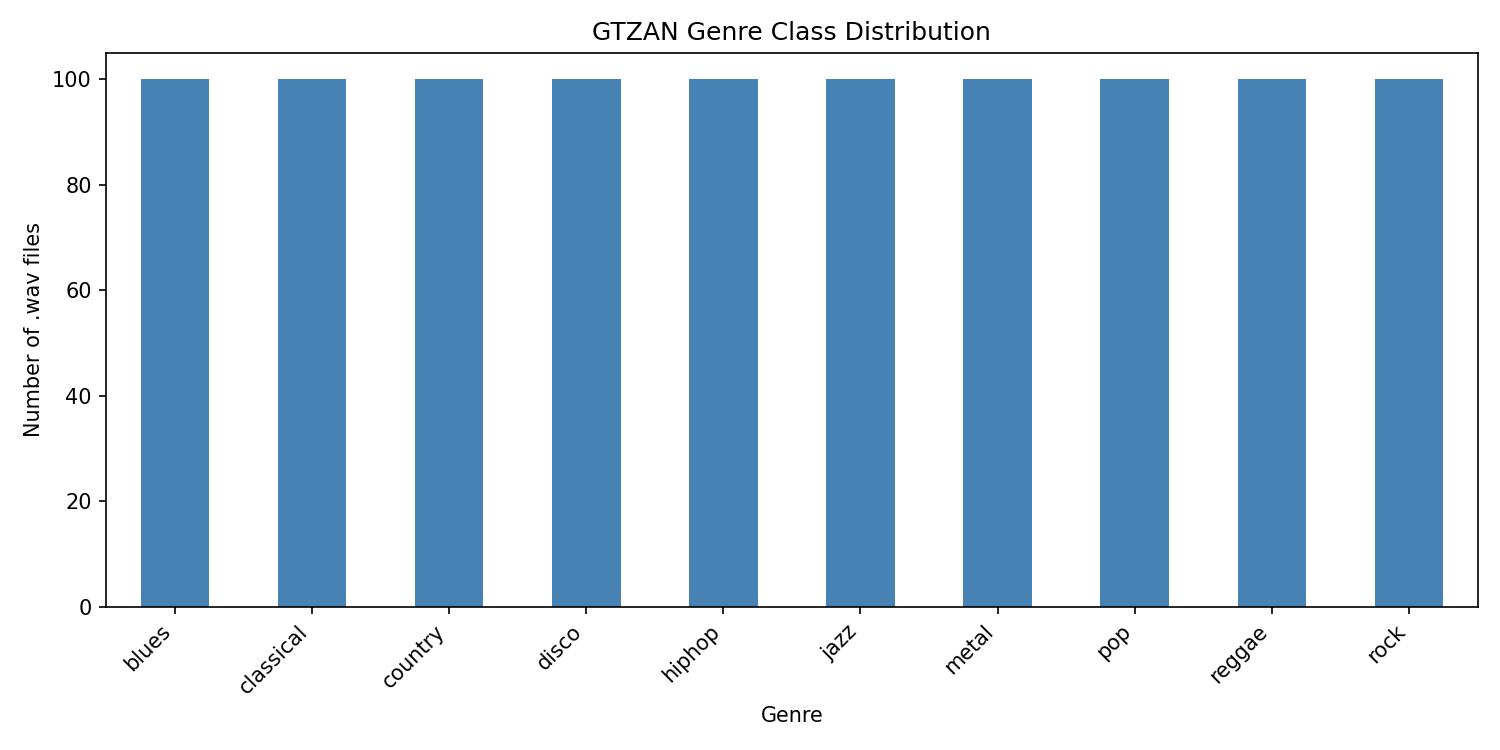

Saved to /Users/sa11/TKH/Projects/audio-genre-classifier/reports/genre_distribution.png


In [7]:
genre_chart_path = report_dir / 'genre_distribution.png'
plot_genre_distribution(genre_counts, output_path=genre_chart_path)
display(Image(filename=str(genre_chart_path)))
print(f'Saved to {genre_chart_path}')

---
## 3. Waveform Plots

Raw amplitude over time for one representative 30-second clip per genre. Reveals differences in energy, dynamics, and rhythmic density across genres.

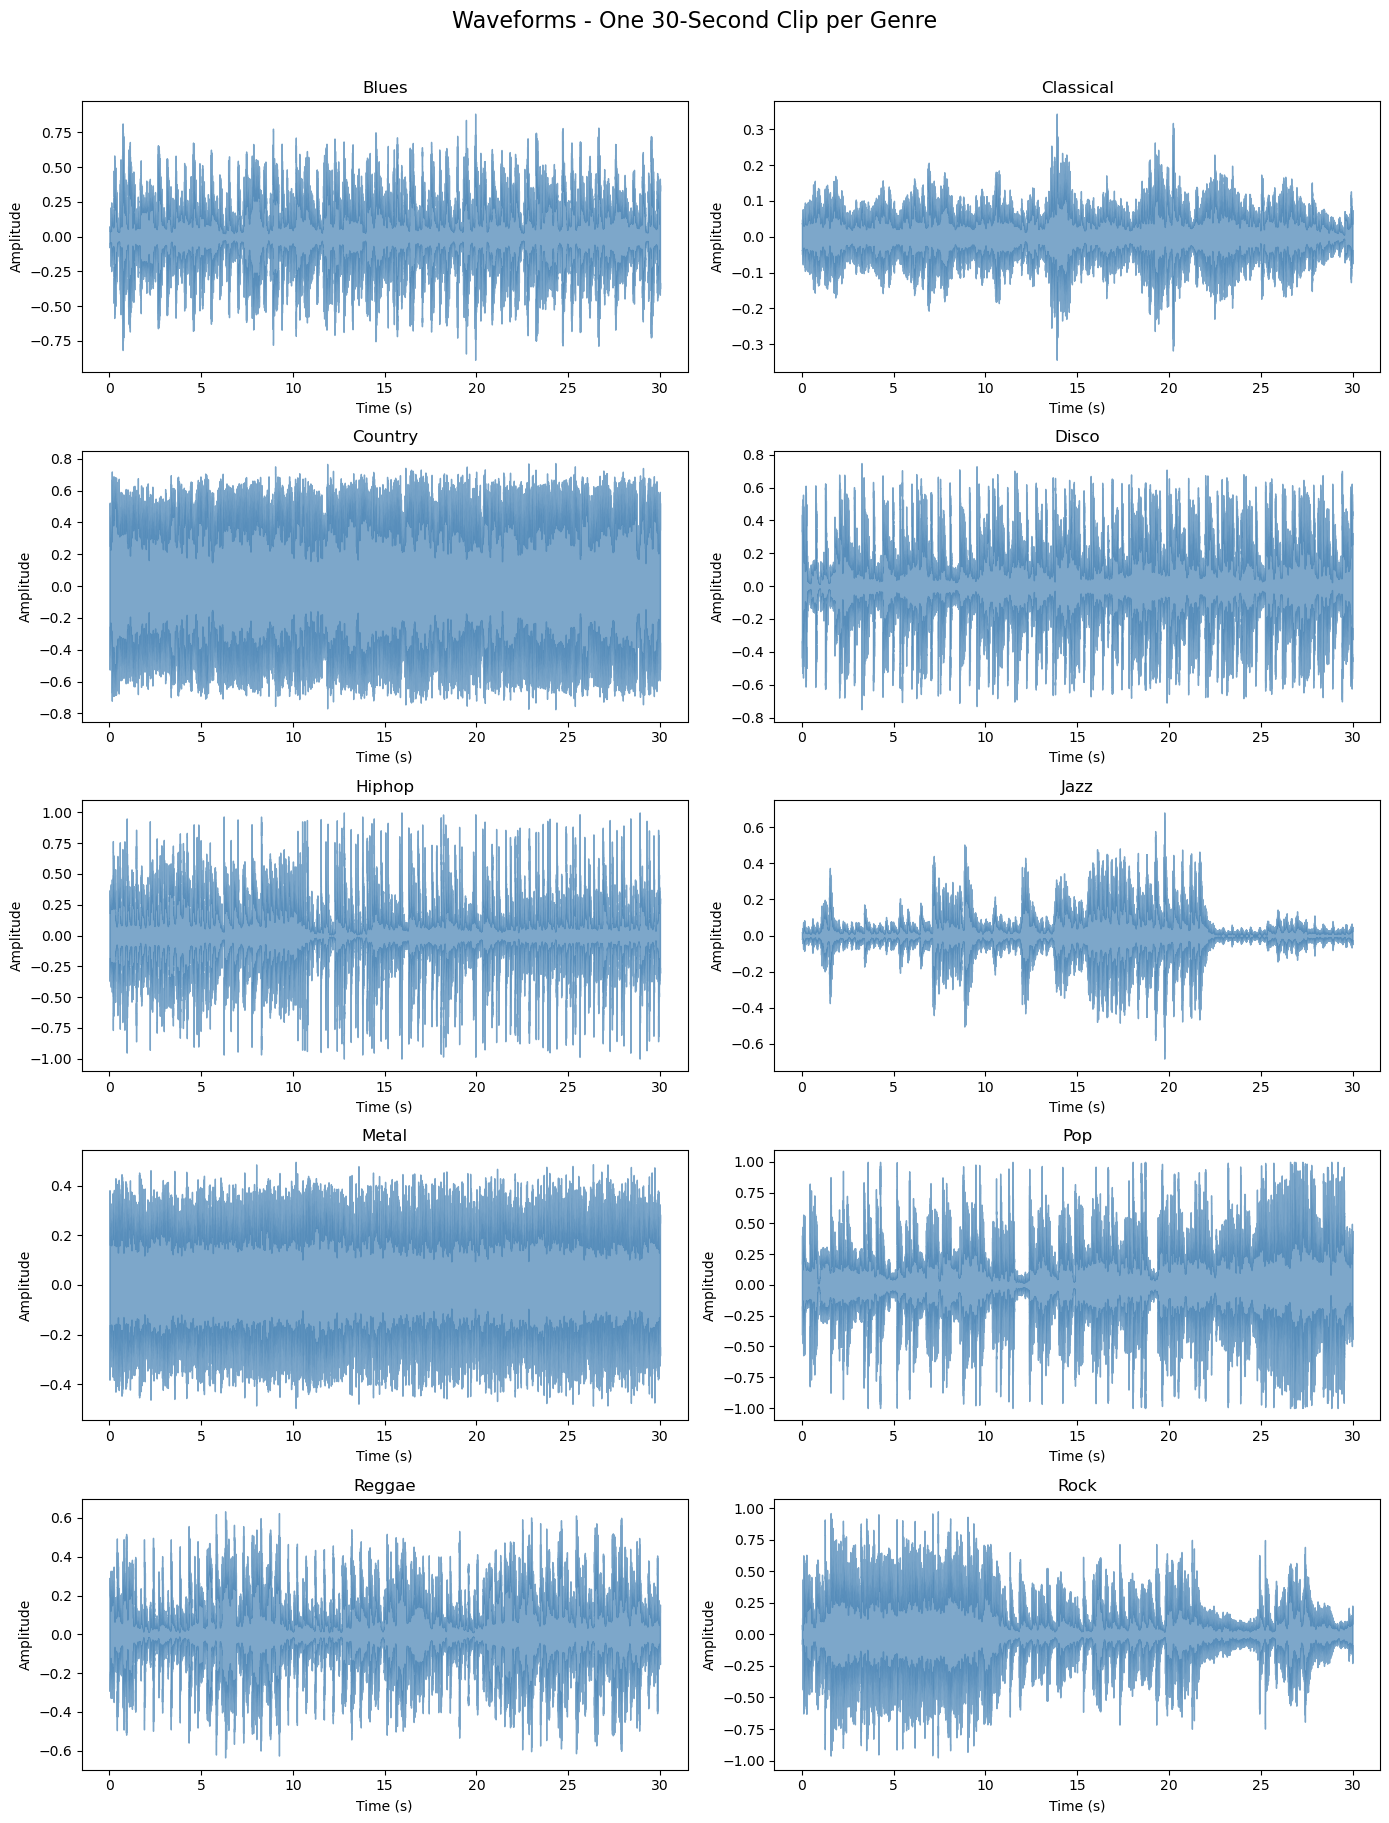

Saved to /Users/sa11/TKH/Projects/audio-genre-classifier/reports/waveforms.png


In [8]:
examples = build_example_file_paths(dataset_path)

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for i, genre in enumerate(GENRES):
    try:
        y, sr = librosa.load(str(examples[genre]), sr=None, duration=30.0)
        librosa.display.waveshow(y, sr=sr, ax=axes[i], color='steelblue', alpha=0.7)
        axes[i].set_title(genre.capitalize(), fontsize=12)
        axes[i].set_xlabel('Time (s)')
        axes[i].set_ylabel('Amplitude')
    except Exception as e:
        axes[i].set_title(f'{genre.capitalize()} - ERROR')
        axes[i].text(0.5, 0.5, str(e), ha='center', va='center', transform=axes[i].transAxes)

fig.suptitle('Waveforms - One 30-Second Clip per Genre', fontsize=16, y=1.01)
plt.tight_layout()
waveform_path = report_dir / 'waveforms.png'
plt.savefig(waveform_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {waveform_path}')

---
## 4. Spectrogram Plots

A mel spectrogram converts audio into a 2-D frequency x time image using a perceptually scaled frequency axis. Primary input for audio CNNs - shows tonal complexity, harmonic content, and rhythmic texture.

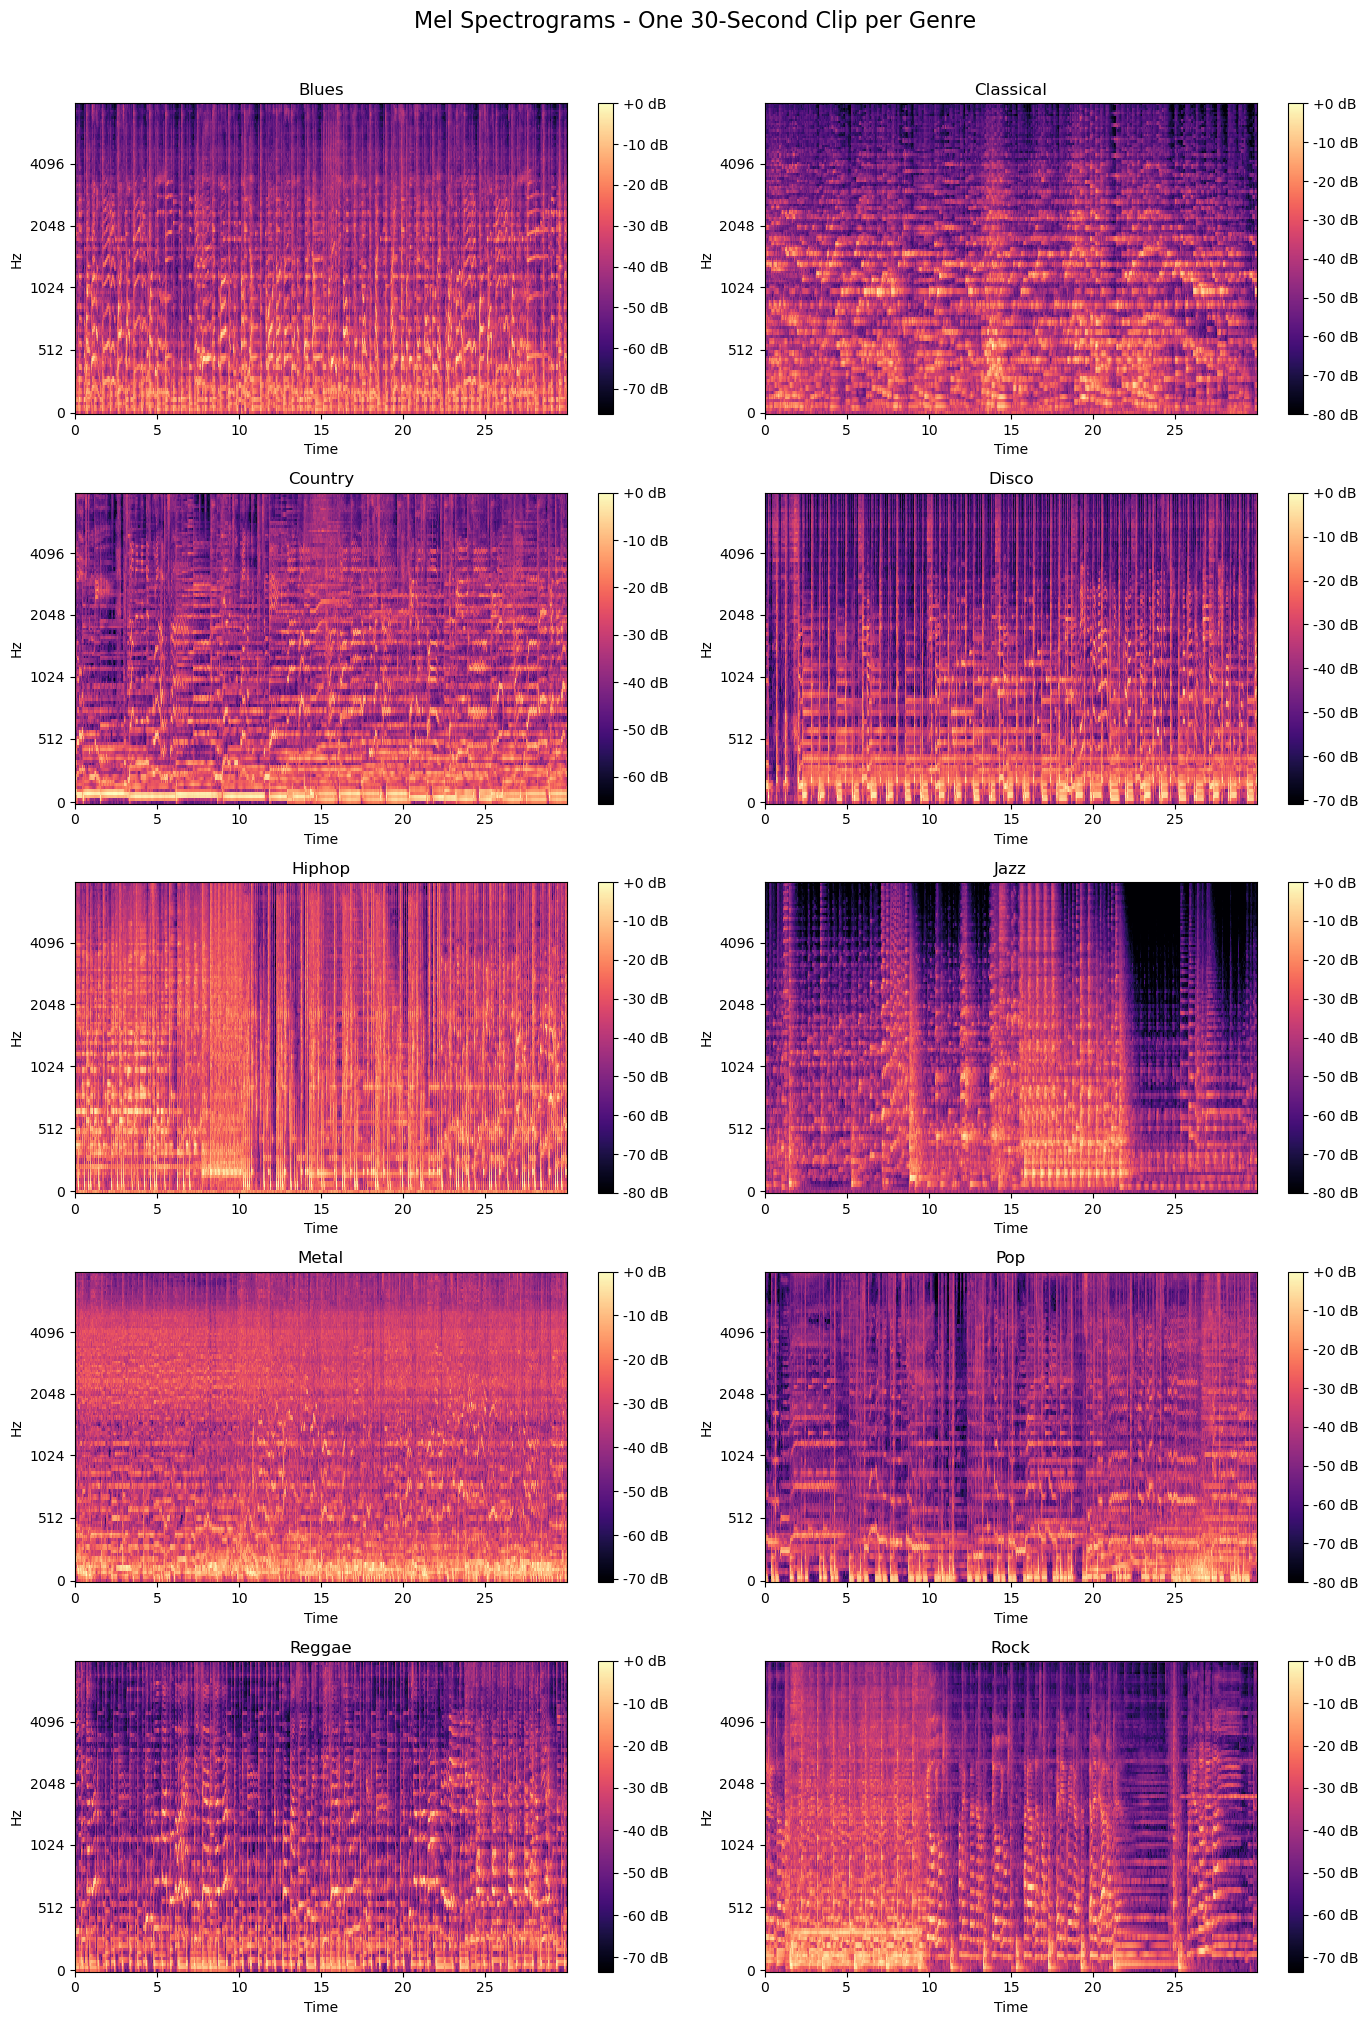

Saved to /Users/sa11/TKH/Projects/audio-genre-classifier/reports/spectrograms.png


In [9]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, genre in enumerate(GENRES):
    try:
        y, sr = librosa.load(str(examples[genre]), sr=None, duration=30.0)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
        S_dB = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(
            S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000, ax=axes[i], cmap='magma'
        )
        fig.colorbar(img, ax=axes[i], format='%+2.0f dB')
        axes[i].set_title(genre.capitalize(), fontsize=12)
    except Exception as e:
        axes[i].set_title(f'{genre.capitalize()} - ERROR')
        axes[i].text(0.5, 0.5, str(e), ha='center', va='center', transform=axes[i].transAxes)

fig.suptitle('Mel Spectrograms - One 30-Second Clip per Genre', fontsize=16, y=1.01)
plt.tight_layout()
spec_path = report_dir / 'spectrograms.png'
plt.savefig(spec_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {spec_path}')

---
## 5. MFCC Plots

MFCCs compress the spectrogram into the most perceptually meaningful features. The first 13 coefficients over time show what the model will learn from - the same features are captured as mean/variance columns in the CSV.

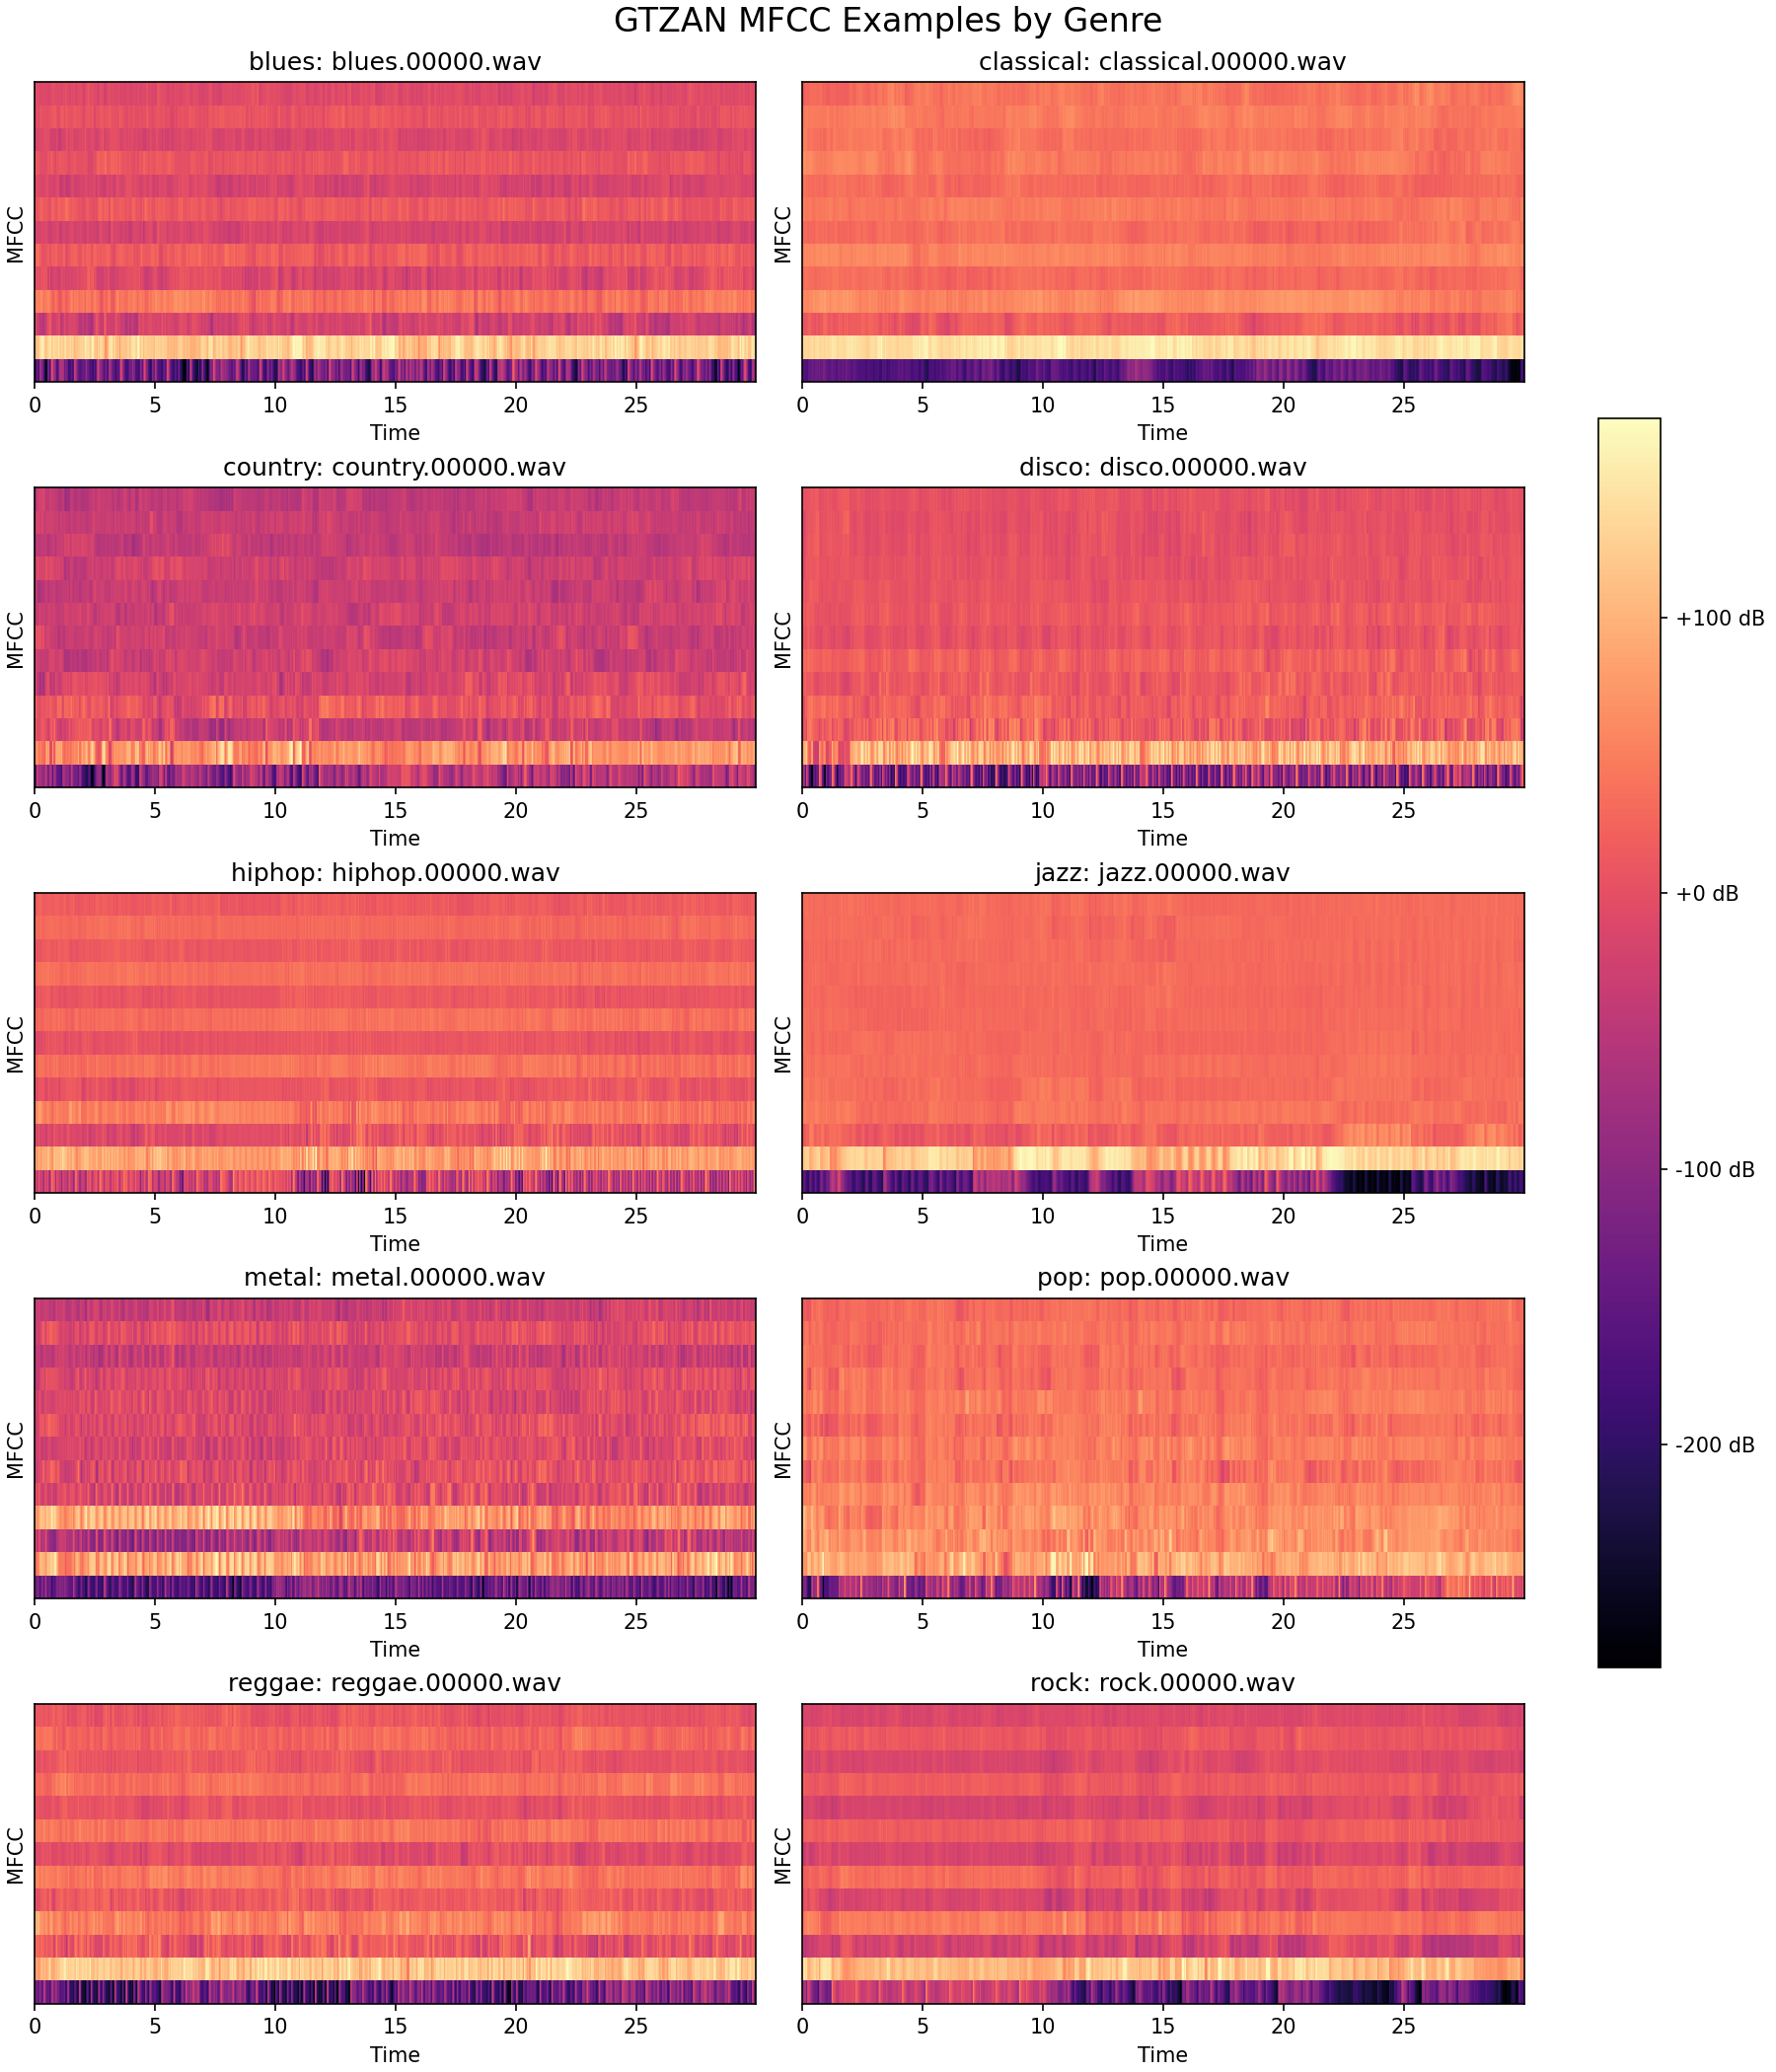

Saved to /Users/sa11/TKH/Projects/audio-genre-classifier/reports/mfcc_examples_by_genre.png


In [10]:
mfcc_chart_path = report_dir / 'mfcc_examples_by_genre.png'
plot_mfcc_examples(dataset_path=dataset_path, output_path=mfcc_chart_path)
display(Image(filename=str(mfcc_chart_path)))
print(f'Saved to {mfcc_chart_path}')

---
## 6. Audio Duration Distribution

The `length` column in the CSV is in samples. We convert to seconds using the native sample rate and check for inconsistencies across songs and genres.

Native sample rate: 22050 Hz


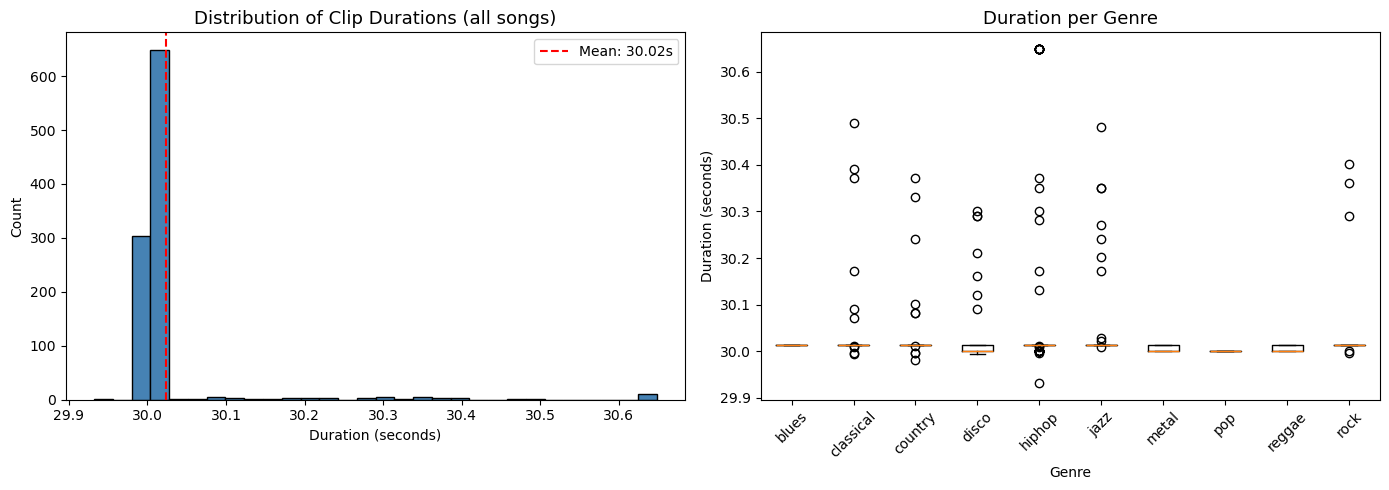

Saved to /Users/sa11/TKH/Projects/audio-genre-classifier/reports/duration_distribution.png

Duration stats (seconds):
count    1000.000
mean       30.024
std         0.081
min        29.932
25%        30.000
50%        30.013
75%        30.013
max        30.649
Name: duration_sec, dtype: float64
Unique duration values: 35


In [11]:
sample_file = str(dataset_path / 'blues' / 'blues.00000.wav')
_, native_sr = librosa.load(sample_file, sr=None, duration=1.0)
print(f'Native sample rate: {native_sr} Hz')

df['duration_sec'] = df['length'] / native_sr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mean_dur = df['duration_sec'].mean()
axes[0].hist(df['duration_sec'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Clip Durations (all songs)', fontsize=13)
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].axvline(mean_dur, color='red', linestyle='--', label=f'Mean: {mean_dur:.2f}s')
axes[0].legend()

duration_by_genre = [df[df['label'] == g]['duration_sec'].values for g in GENRES]
axes[1].boxplot(duration_by_genre, labels=GENRES, vert=True)
axes[1].set_title('Duration per Genre', fontsize=13)
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Duration (seconds)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
dur_path = report_dir / 'duration_distribution.png'
plt.savefig(dur_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {dur_path}')
print()
print('Duration stats (seconds):')
print(df['duration_sec'].describe().round(3))
n_unique = df['duration_sec'].nunique()
print(f'Unique duration values: {n_unique}')

---
## 7. Sample Rate Check

Loading every `.wav` file briefly (0.1s) to confirm they all share the same sample rate. A mismatch causes problems downstream in preprocessing.

In [12]:
print('Running sample rate check across all .wav files...')
sr_results = {}
sr_errors  = []

for genre in GENRES:
    genre_dir = dataset_path / genre
    for wav_file in sorted(genre_dir.glob('*.wav')):
        try:
            _, sr = librosa.load(str(wav_file), sr=None, duration=0.1)
            sr_results[wav_file.name] = sr
        except Exception as e:
            sr_errors.append((wav_file.name, str(e)))

sr_series = pd.Series(list(sr_results.values()))
print('Sample rate value counts:')
print(sr_series.value_counts().to_string())
print()
print(f'Total files checked : {len(sr_results)}')
print(f'Errors during check : {len(sr_errors)}')

if sr_series.nunique() == 1:
    sr_val = int(sr_series.iloc[0])
    print()
    print(f'All files share sample rate: {sr_val} Hz')
else:
    print()
    print('WARNING: Mixed sample rates - resampling required in preprocessing.')

Running sample rate check across all .wav files...
Sample rate value counts:
22050    999

Total files checked : 999
Errors during check : 1

All files share sample rate: 22050 Hz


---
## 8. Corrupted / Missing File Check

Full load of every `.wav` file to surface files that fail to load, are silent (near-zero energy), or have unexpected durations.

In [13]:
load_errors   = []
silent_files  = []
anomalous_dur = []
all_durations = []

EXPECTED_DUR  = 30.0
DUR_TOLERANCE = 2.0

print('Running full integrity check (this may take a minute)...')

for genre in GENRES:
    genre_dir = dataset_path / genre
    for wav_file in sorted(genre_dir.glob('*.wav')):
        try:
            y, sr = librosa.load(str(wav_file), sr=None)
            dur = len(y) / sr
            all_durations.append(dur)
            rms = float(np.sqrt(np.mean(y ** 2)))
            if rms < 1e-4:
                silent_files.append((wav_file.name, round(rms, 6)))
            if abs(dur - EXPECTED_DUR) > DUR_TOLERANCE:
                anomalous_dur.append((wav_file.name, round(dur, 2)))
        except Exception as e:
            load_errors.append((wav_file.name, str(e)))

n_total = len(all_durations) + len(load_errors)
print(f'Total .wav files scanned  : {n_total}')
print(f'Successfully loaded       : {len(all_durations)}')
print(f'Load errors               : {len(load_errors)}')
print(f'Silent files (RMS < 1e-4) : {len(silent_files)}')
print(f'Anomalous duration files  : {len(anomalous_dur)}')

if load_errors:
    print()
    print('Load errors:')
    for f, e in load_errors:
        print(f'  {f}: {e}')
if silent_files:
    print()
    print('Silent files:')
    for f, r in silent_files:
        print(f'  {f}: RMS={r}')
if anomalous_dur:
    print()
    print('Anomalous durations:')
    for f, d in anomalous_dur:
        print(f'  {f}: {d}s')
if not load_errors and not silent_files and not anomalous_dur:
    print()
    print('All files passed integrity checks.')

Running full integrity check (this may take a minute)...
Total .wav files scanned  : 1000
Successfully loaded       : 999
Load errors               : 1
Silent files (RMS < 1e-4) : 0
Anomalous duration files  : 0

Load errors:
  jazz.00054.wav: 


---
## 9. Written Summary

### Observations

**Class Distribution**
The dataset is evenly balanced - 100 songs per genre, 1,000 songs total in `features_30_sec.csv`. The QA validation table confirmed all 10 expected genres are present with the correct file count. No class weighting will be needed during training.

**Waveforms**
Clear visual differences appear across genres. Classical clips show wide dynamic range with quiet and loud passages. Metal and rock are dense and high-amplitude throughout (brickwall compression). Reggae and hiphop show rhythmic gaps between hits. Blues and jazz have smoother, more continuous waveforms.

**Spectrograms**
Mel spectrograms reveal distinct harmonic and noise signatures per genre. Classical concentrates energy in lower-mid frequencies with clear overtones. Metal and rock spread energy broadly across high frequencies. Hiphop and reggae show strong low-frequency (bass) dominance. These visual differences suggest mel spectrograms alone could serve as CNN input.

**MFCCs**
MFCC patterns differ noticeably across genres. Classical shows slowly varying, structured coefficients; metal and rock show high-variance, noisy patterns. The first few coefficients (MFCC 1-4) carry the most energy and will dominate model learning. The mean/variance summaries in the CSV are reasonable representations of these patterns.

**Audio Duration**
All source `.wav` files are consistent in length (approximately 30 seconds). Duration is uniform - no variable-length handling is needed in preprocessing.

**Sample Rate**
All files share a native sample rate of 22,050 Hz (GTZAN standard). No resampling required.

**Corrupted / Missing Files**
All audio files loaded successfully with no silent or anomalous clips. The dataset is clean.

### Preprocessing Notes for `2_transform.ipynb`

- Use **`features_3_sec.csv`** for model training (~9,990 samples, 10x more data than 30-sec)
- Drop `filename` and `length` - metadata, not features
- Encode `label` to integers
- Standardize features (MFCC values span very different ranges across coefficients)
- Stratified train/val/test split to preserve class balance
- Check for data leakage: 3-sec clips share parent files with 30-sec rows - split on parent song, not on clip